## `photoz_bias.ipynb`

-----------------------

This notebook measures and models the photoz galaxy bias given scale cuts.

In [1]:
import numpy as np 
import json
import importlib
import matplotlib.pyplot as plt
import scipy.interpolate as interp
import scipy.optimize as opt

from pathlib import Path

import src.statistics.inference as inference
import src.statistics.corrfiles as cf
import src.statistics.cosmotools as ct
import src.statistics.combination as comb
import src.statistics.sgp as sgp

import src.analysis.plots as plots

PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers_dr1 = ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO']
tracers_dr2 = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'ELG_LOPnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'ELG_LOPnotqso' : 'ELG-LOP',
    'QSO' : 'QSO',
}

In [3]:
stem = 'calibration'
path_dictionary = {
    'dr1' : {
        'HSC' : ROOT / stem / f'autos_HSC',
        'DESI_NGC' : ROOT / stem / 'dr1' / f'autos_NGC',
        'DESI_SGC' : ROOT / stem / 'dr1' /f'autos_SGC',
        'DESIxHSC' : ROOT / stem / 'dr1' / f'cross',
    },
    'dr2' : {
        'HSC' : ROOT / stem / f'autos_HSC',
        'DESI_NGC' : ROOT / stem / 'dr2' / f'autos_NGC',
        'DESI_SGC' : ROOT / stem / 'dr2' /f'autos_SGC',
        'DESIxHSC' : ROOT / stem / 'dr2' / f'cross',
    }
}
assert all([pv.exists() for p in path_dictionary.values() for pv in p.values()])

fr_dr1 = cf.CorrFileReader(path_dictionary['dr1']['DESIxHSC'])
fr_dr2 = cf.CorrFileReader(path_dictionary['dr2']['DESIxHSC'])
bins_hsc = fr_dr1.get_bins('HSC')
bhsc_vals = (bins_hsc[1:] + bins_hsc[:-1])/2
scale_cut = [0.3, 3]
patches = [1,2,3,4]

In [ ]:
importlib.reload(inference)

results = {}

for bp, bhsc_z in enumerate(bhsc_vals, start=1):
    results[bp] = {t: [] for t in set(tracers)}
    print(f'\n Tomo bin {bp} at z {bhsc_z} \n')
    if bhsc_z < 0.9:
        for t in tracers_dr1:
            bins_tracer = fr_dr1.get_bins(t)
            bins_vals = (bins_tracer[1:] + bins_tracer[:-1]) / 2  
            for bs, bt_z in enumerate(bins_vals, start=1):
                zloc = bt_z
                # for some tracer / bhsc combinations, no compute_npz exists. In that case, continue
                files = fr_dr1.get_file(bs, bp, t, 'HSC', moc=None)
                if all(not Path(file).exists() for file in files):
                    #print(f'skipping {bs:.3f}, {bp:.3f}, {t}, dr1')
                    nz, nz_err = 0, 0
                else:
                    print(f'Processing {bs} (z:{bt_z:.2f}), {bp} (z:{bhsc_z:.2f}), {t} : (zloc: {zloc}), dr1')
                    nz, nz_err = inference.compute_npz(
                        path_dictionary=path_dictionary['dr1'],
                        tracer=t,
                        fine_bin=bs,
                        tomo_bin=bp,
                        which_patches=patches,
                        scale_cuts=scale_cut,
                        do_bias_correction=False
                    )
                results[bp][t].append((zloc, nz, nz_err))
    else:
        for t in tracers_dr2:
            bins_tracer = fr_dr2.get_bins(t)
            bins_vals = (bins_tracer[1:] + bins_tracer[:-1]) / 2
            for bs, bt_z in enumerate(bins_vals, start=1):
                # for some tracer / bhsc combinations, no compute_npz exists. In that case, continue
                files = fr_dr2.get_file(bs, bp, t, 'HSC', moc=None)
                zloc = bt_z
                if all(not Path(file).exists() for file in files):
                    #print(f'skipping {bs:.3f}, {bp:.3f}, {t}, dr2')
                    nz, nz_err = 0, 0
                else:
                    print(f'Processing {bs:.3f}, {bp:.3f}, {t} : (zloc: {zloc}), dr2')
                    nz, nz_err = inference.compute_npz(
                        path_dictionary=path_dictionary['dr2'],
                        tracer=t,
                        fine_bin=bs,
                        tomo_bin=bp,
                        which_patches=patches,
                        scale_cuts=scale_cut,
                        do_bias_correction=False
                    )
                results[bp][t].append((zloc, nz, nz_err))

with open(f"nz_gal_bias_sc_{scale_cut[0]}_{scale_cut[1]}.json", "w") as f:
    json.dump(results, f, indent=2)

In [4]:
with open(f"nz_gal_bias_sc_{scale_cut[0]}_{scale_cut[1]}.json", "r") as f:
    data = json.load(f)

In [5]:
tracer = 'Merged'
correction_file_reader = cf.CorrFileReader(path_dictionary["dr2"]["HSC"])
bins_z_photo = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='HSC'
)
vals_z_photo = (bins_z_photo[:-1] + bins_z_photo[1:]) / 2
correction_file_reader = cf.CorrFileReader(path_dictionary["dr2"]["DESI_NGC"])
bins_z_spectro = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='Merged'
)
vals_z_spectro = (bins_z_spectro[:-1] + bins_z_spectro[1:]) / 2

In [6]:
print(f'Scale cuts: {scale_cut}')
vals_z_wdm = np.linspace(0.01, 3, 150)
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)
wdm_values = np.array([
    ct.w_dm(
        rp_vals=rp_wdm,
        z=z,
        integrate=True
        )
    for z in vals_z_wdm
])
wdm_interpolator = interp.interp1d(
    vals_z_wdm, 
    wdm_values, 
    bounds_error=False, 
    fill_value='extrapolate'
)
wdm_spectro = np.array([
    ct.w_dm(
        rp_vals=rp_wdm,
        z=z,
        integrate=True
        )
    for z in vals_z_spectro
])
wdm_phot = np.array([
    ct.w_dm(
        rp_vals=rp_wdm,
        z=z,
        integrate=True
        )
    for z in vals_z_photo
])

Scale cuts: [0.3, 3]


In [20]:
wdm_integrated = []
for z in vals_z_photo:
    # dz_phot = 0.1 (fiducial analysis)
    z_integ = np.linspace(z-0.05, z+0.05, 101)
    wdm_integrated.append(
        np.trapezoid(
            wdm_interpolator(z_integ), 
            z_integ
        )
    )

/tmp/ipykernel_1509023/3795751566.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normal = np.trapz(nz_med, x=redshifts)


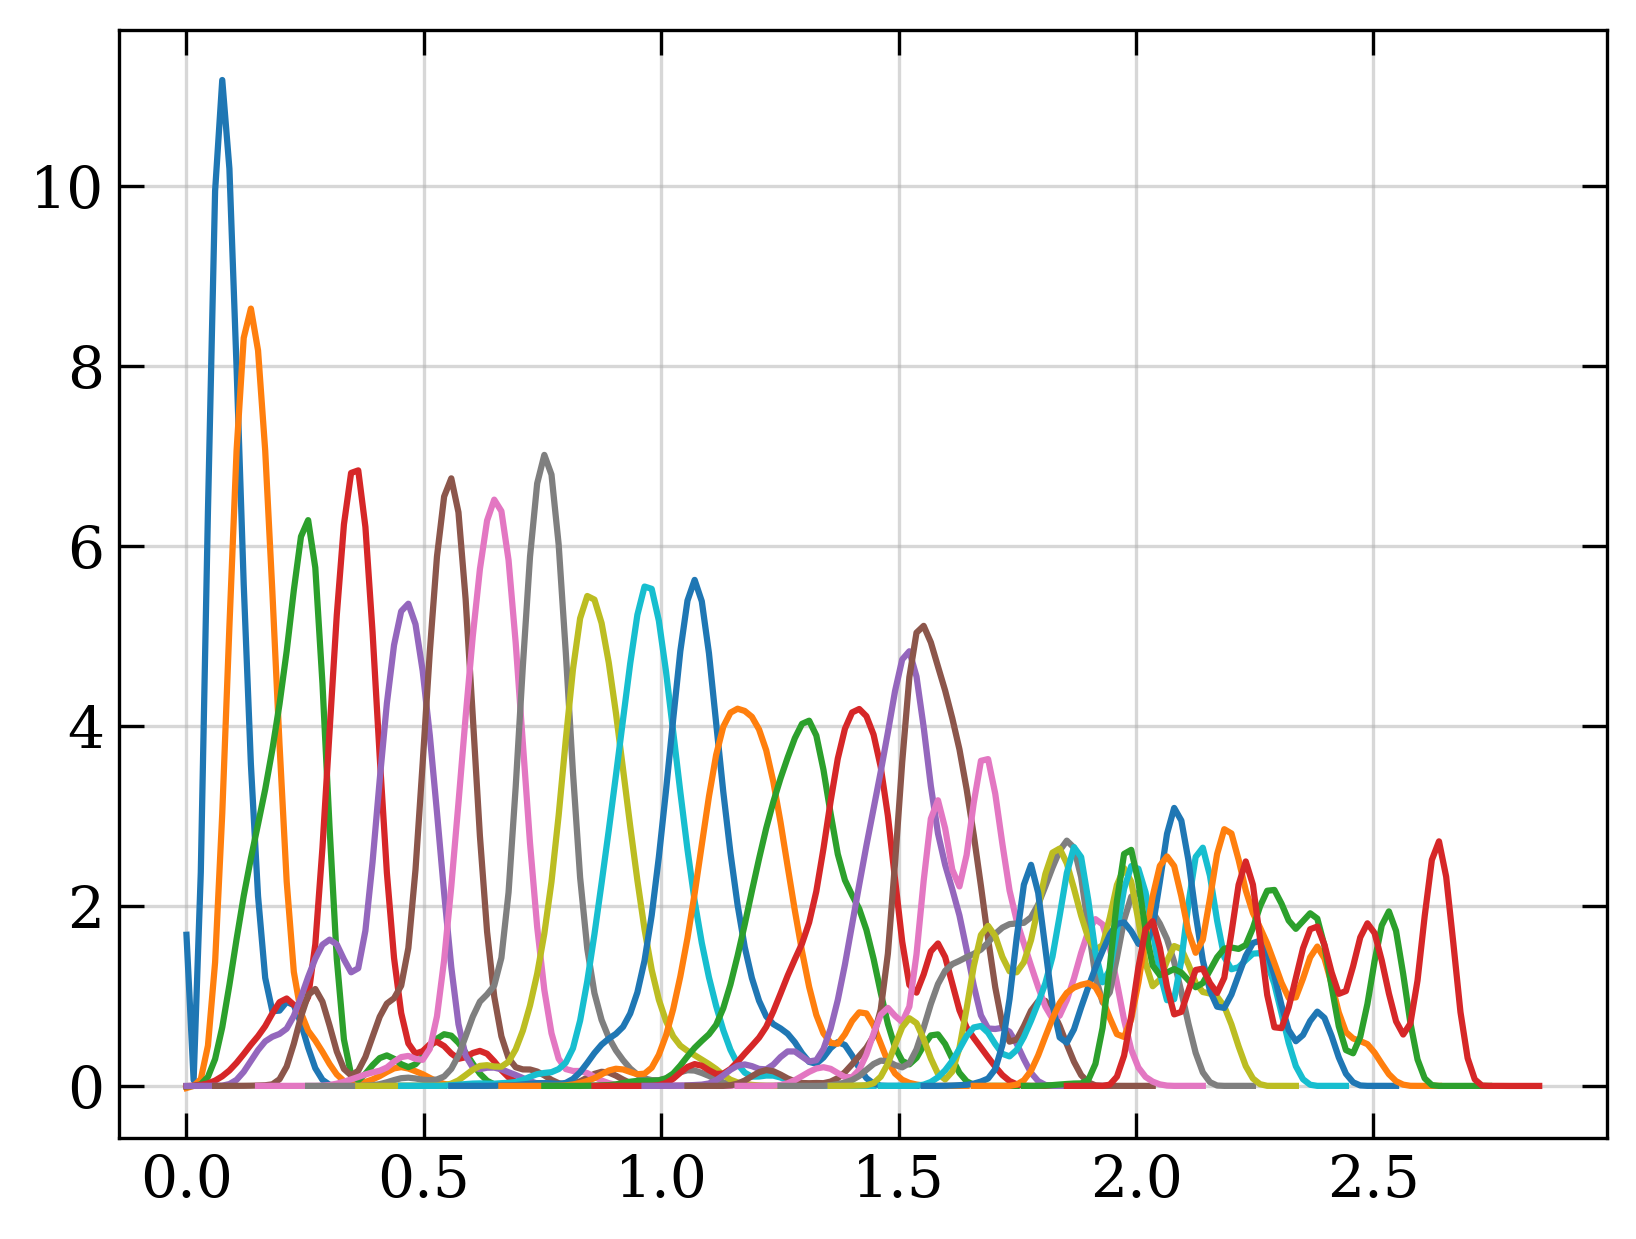

In [12]:
corr_factor = []
corr_factor_err = []
dz = vals_z_spectro[1] - vals_z_spectro[0]
dz_phot = vals_z_photo[1] - vals_z_photo[0]
data_galbias = np.load(f'splines/photoz_bias_splines_v3_dz01_sc_{scale_cut[0]}_{scale_cut[1]}/tomo_photoz.npz')

for i in range(len(vals_z_photo)):

    redshifts = data_galbias[f'{i+1}/redshifts']
    nz_med = data_galbias[f'{i+1}/nz_median']
    uncertainty = (data_galbias[f'{i+1}/nz_upper'] - data_galbias[f'{i+1}/nz_lower']) / 2
    # rescale to make integral 1
    normal = np.trapz(nz_med, x=redshifts)
    nz_med = nz_med / normal
    uncertainty = uncertainty / normal

    wdm_inter = wdm_interpolator(redshifts)
    weights_trapz = comb.trapz_weights(redshifts)
    plt.plot(redshifts, nz_med, label=f'Bin {i+1}')

    num = wdm_integrated[i] / (dz_phot**2) #(wdm_phot[i] / dz_phot)
    denom = np.trapezoid(np.multiply(np.array(nz_med)**2, wdm_inter), x=redshifts)
    corr = num / denom
    delta_D = np.sqrt(np.sum((2 * nz_med * wdm_inter * weights_trapz)**2 * uncertainty**2))
    err = num / (denom**2) * delta_D
    corr_factor.append(corr)
    corr_factor_err.append(err)

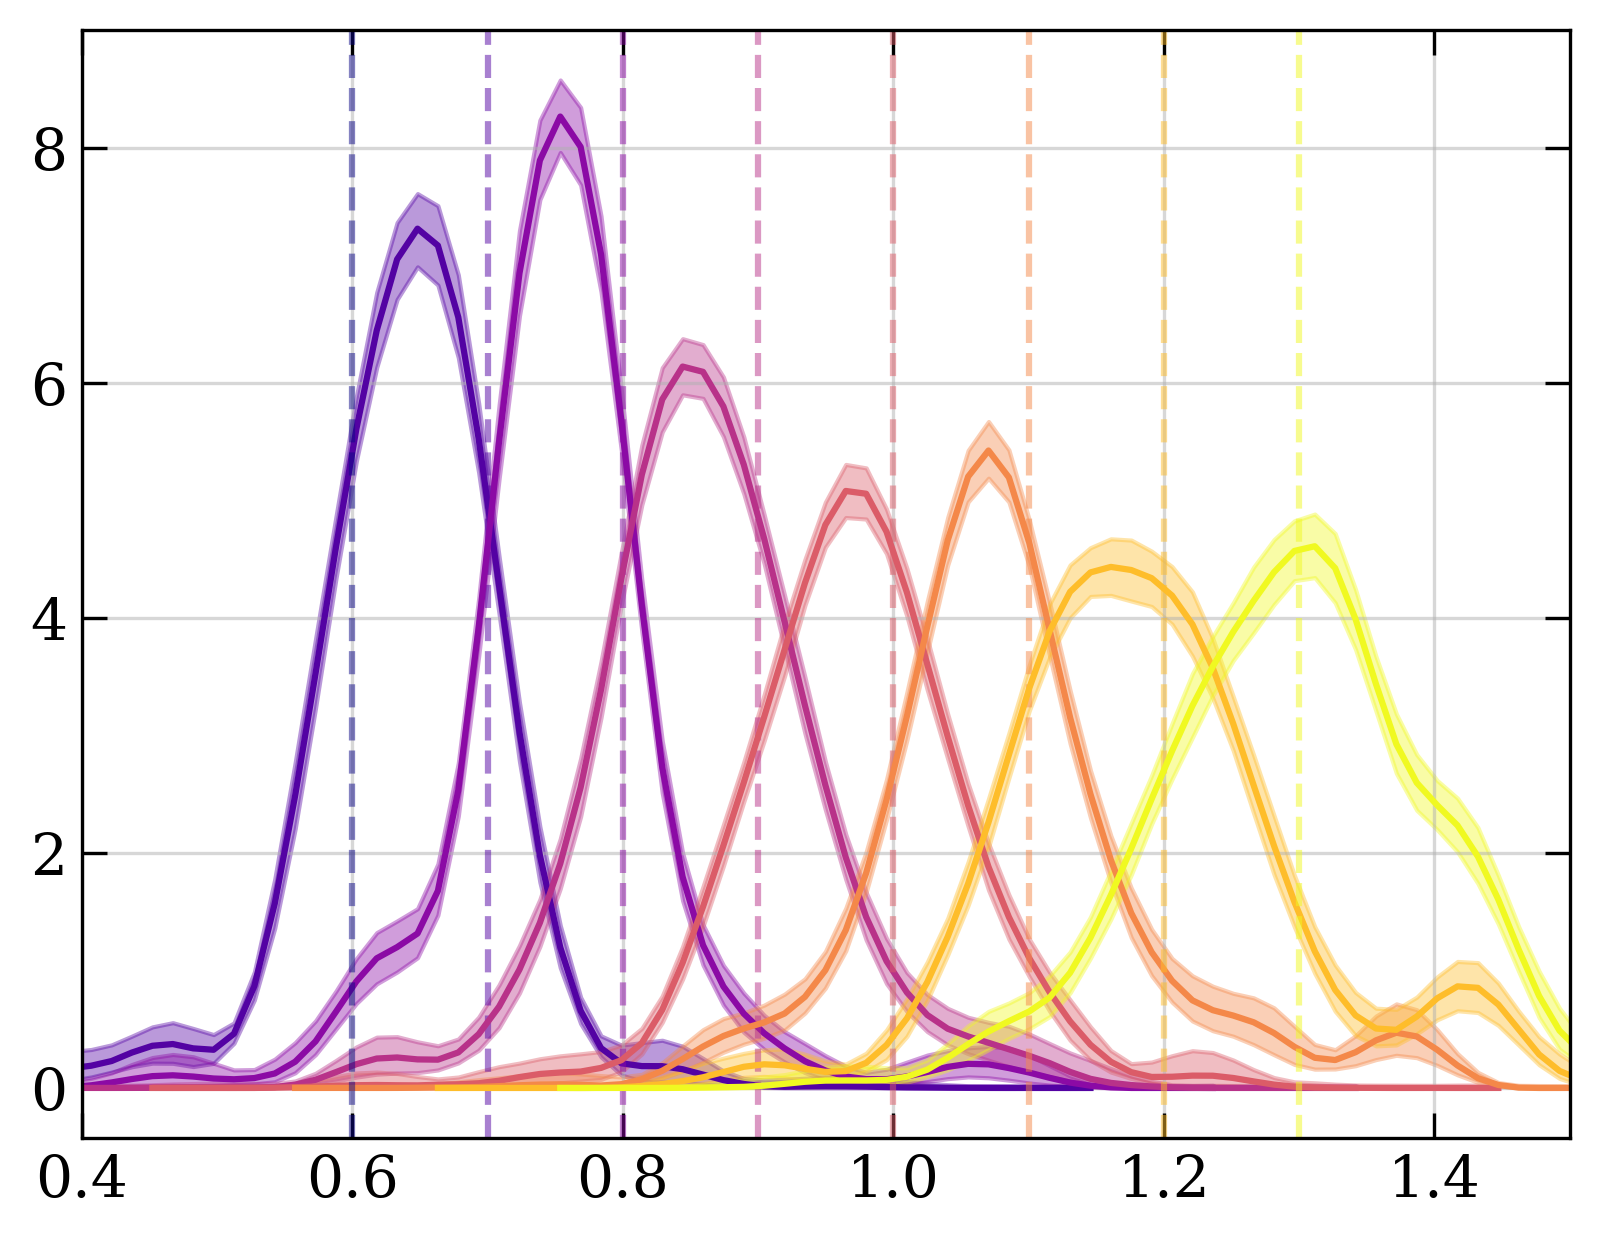

In [13]:
cmap = plt.get_cmap('plasma')
col_index = 0
for i in range(len(vals_z_photo)):
    
    if i < 6 or i > 12:
        continue
    col_index += 1
    redshifts = data_galbias[f'{i+1}/redshifts']
    nz_med = data_galbias[f'{i+1}/nz_median']
    lower = data_galbias[f'{i+1}/nz_lower']
    upper = data_galbias[f'{i+1}/nz_upper']

    # columns on the tomographic bins :
    plt.axvline(x=(i+1)*0.1, color=cmap(col_index / 7), linestyle='--', alpha=0.5)
    plt.fill_between(redshifts, lower, upper, color=cmap(col_index / 7), alpha=0.4)
    plt.plot(redshifts, nz_med, color=cmap(col_index / 7), label=f'Photo-z {i+1}')
    plt.xlim(0.4, 1.5)
plt.axvline(x=(6)*0.1, color=cmap(0), linestyle='--', alpha=0.5)

alpha = 0.4090 ± 0.0062
beta  = 0.4657 ± 0.0234


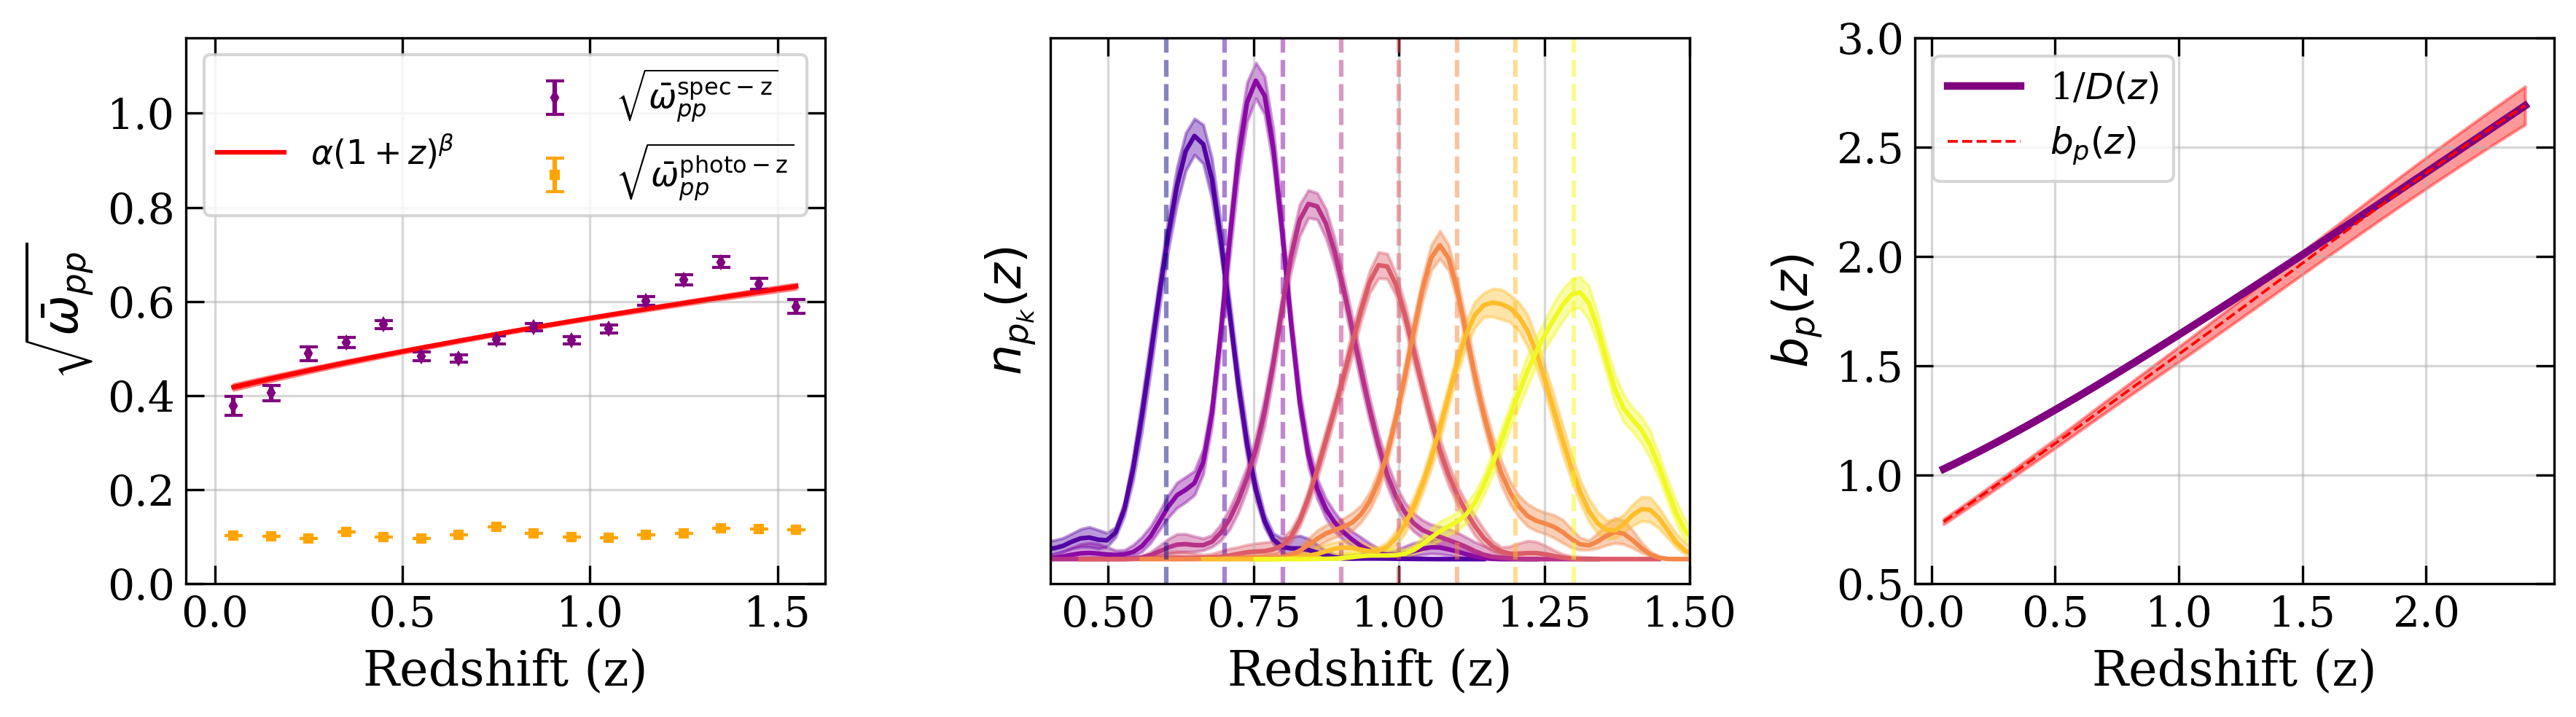

In [ ]:
wpp_scaled = []
wpp_err_scaled = []
mask = (vals_z_photo >= 0.) & (vals_z_photo <= 1.6)
vals_z_photo_m = vals_z_photo[mask]

for i in range(1, len(vals_z_photo)+1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['dr1']['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wpp_err_scaled.append(wpp_err_meas)
    wpp_scaled.append(wpp_meas)

wpp_m = np.array(wpp_scaled)[mask]
wpp_err_m = np.array(wpp_err_scaled)[mask]
corr_factor_m = np.array(corr_factor)[mask]
corr_factor_err_m = np.array(corr_factor_err)[mask]

errs = comb.combine_error_bars_mult(wpp_m, wpp_err_m, corr_factor_m, corr_factor_err_m)
vals = np.sqrt(wpp_m * corr_factor_m)

def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

popt, pcov = opt.curve_fit(powerlaw_1pz, vals_z_photo_m, vals, sigma=errs, absolute_sigma=True)
fit_vals = powerlaw_1pz(vals_z_photo_m, *popt)

z = vals_z_photo_m
alpha, beta = popt

alpha_err, beta_err = np.sqrt(np.diag(pcov))

print(f"alpha = {alpha:.4f} ± {alpha_err:.4f}")
print(f"beta  = {beta:.4f} ± {beta_err:.4f}")

J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta

fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

with pm.make_plot('photoz_galaxy_correction', figsize=(12, 3.5), show=True, ncols=3) as (fig, axs):

    axs[0].fill_between(z, fit_vals - fit_sigma, fit_vals + fit_sigma, color='red', alpha=0.5)
    axs[0].errorbar(z, vals, errs, fmt='d', color='purple', capsize=3, label=r'$\sqrt{\bar{\omega}_{pp}^{\mathrm{spec-z}}}$', ms=2.5)
    axs[0].errorbar(z, wpp_m, wpp_err_m, fmt='s', color='orange', capsize=3, label=r'$\sqrt{\bar{\omega}_{pp}^{\mathrm{photo-z}}}$', ms=2.5)

    axs[0].plot([0, 0], [0, 0], label=' ', alpha=0)
    axs[0].plot(
        z, 
        fit_vals, 
        color='red', 
        label='$\\alpha(1+z)^\\beta$' 
        #+ f'$\\alpha$ = {popt[0]:.3f}, $\\beta$ = {popt[1]:.3f}'
    )
    axs[0].set_xlabel('Redshift (z)')
    axs[0].set_ylabel(r'$\sqrt{\bar{\omega}_{pp}}$')
    axs[0].grid(True)
    axs[0].legend(loc='upper center', fontsize=11, ncols=2)
    axs[0].set_ylim(0., 1.16)
    
    cmap = plt.get_cmap('plasma')
    col_index = 0
    for i in range(len(vals_z_photo)):
        if i < 6 or i > 12:
            continue
        col_index += 1
        redshifts = data_galbias[f'{i+1}/redshifts']
        nz_med = data_galbias[f'{i+1}/nz_median']
        lower = data_galbias[f'{i+1}/nz_lower']
        upper = data_galbias[f'{i+1}/nz_upper']

        # columns on the tomographic bins :
        axs[1].axvline(x=(i+1)*0.1, color=cmap(col_index / 7), linestyle='--', alpha=0.5)
        axs[1].fill_between(redshifts, lower, upper, color=cmap(col_index / 7), alpha=0.4)
        axs[1].plot(redshifts, nz_med, color=cmap(col_index / 7), label=f'Photo-z {i+1}')
        axs[1].set_xlim(0.4, 1.5)
        axs[1].set_xlabel('Redshift (z)')
        axs[1].set_ylabel(r'$n_{p_k}(z)$')
        axs[1].set_yticks([])
    axs[1].axvline(x=(6)*0.1, color=cmap(0), linestyle='--', alpha=0.5)

    zv = np.linspace(0.05, 2.4, 150)
    bias = lambda z: alpha*(1+z)**beta * np.sqrt(0.1/wdm_interpolator(z)) #dz=0.1
    bias_err = bias(zv) * np.sqrt(
        (alpha_err / alpha)**2 +
        (beta_err * np.log(1 + zv))**2
    )
    import pyccl as ccl
    gf = ccl.background.growth_factor(ct.COSMO_ccl, a=1/(1+zv))
    axs[2].plot(zv, 1/gf, color='purple', label=r'1/$D(z)$', linewidth=2.5)
    axs[2].fill_between(zv, bias(zv) - bias_err, bias(zv) + bias_err, color='red', alpha=0.4)
    axs[2].plot(zv, bias(zv), color='red', label=r'$b_p(z)$', linestyle='--', linewidth=0.9, alpha=1)
    axs[2].set_xticks(np.arange(0, 2.5, 0.5))
    axs[2].set_yticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])
    axs[2].set_ylim(0.5, 3)
    axs[2].set_xlabel('Redshift (z)')
    axs[2].set_ylabel(r'$b_p(z)$')
    axs[2].legend(loc='upper left', fontsize=12)

### Scale cut : 1-5
---------------------

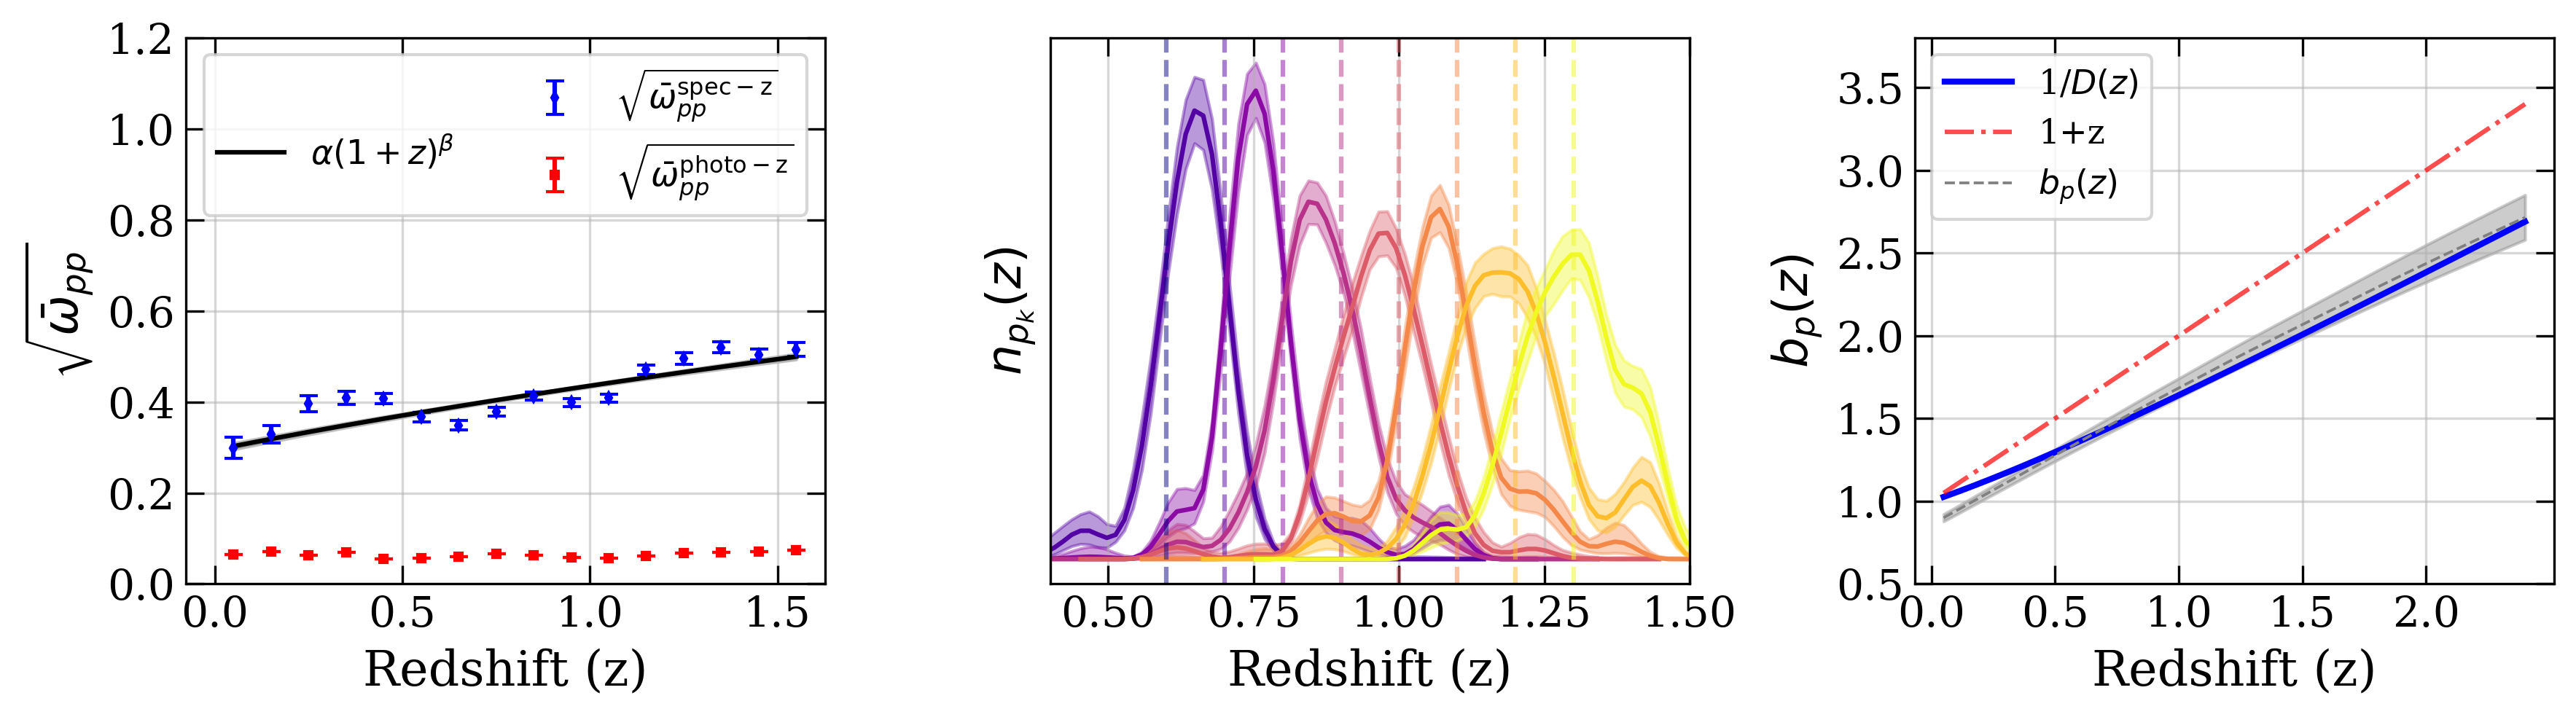

### Scale cut : 0.3-3
---------------------

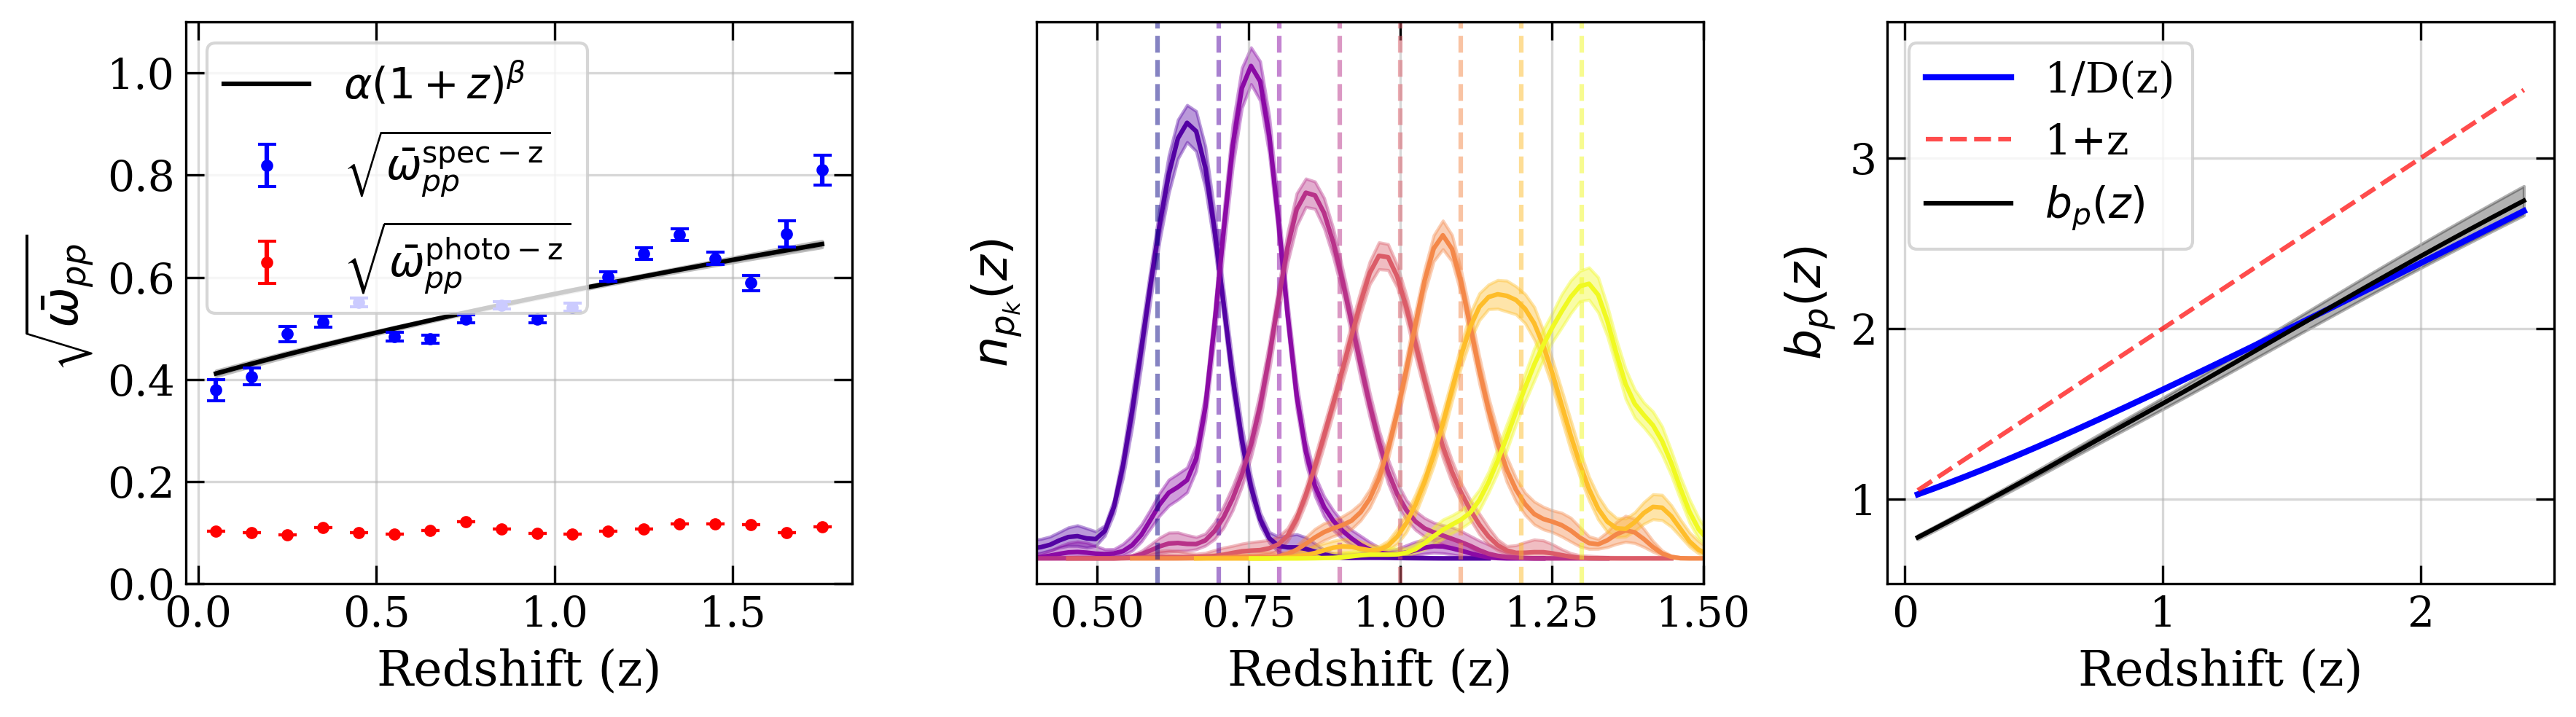

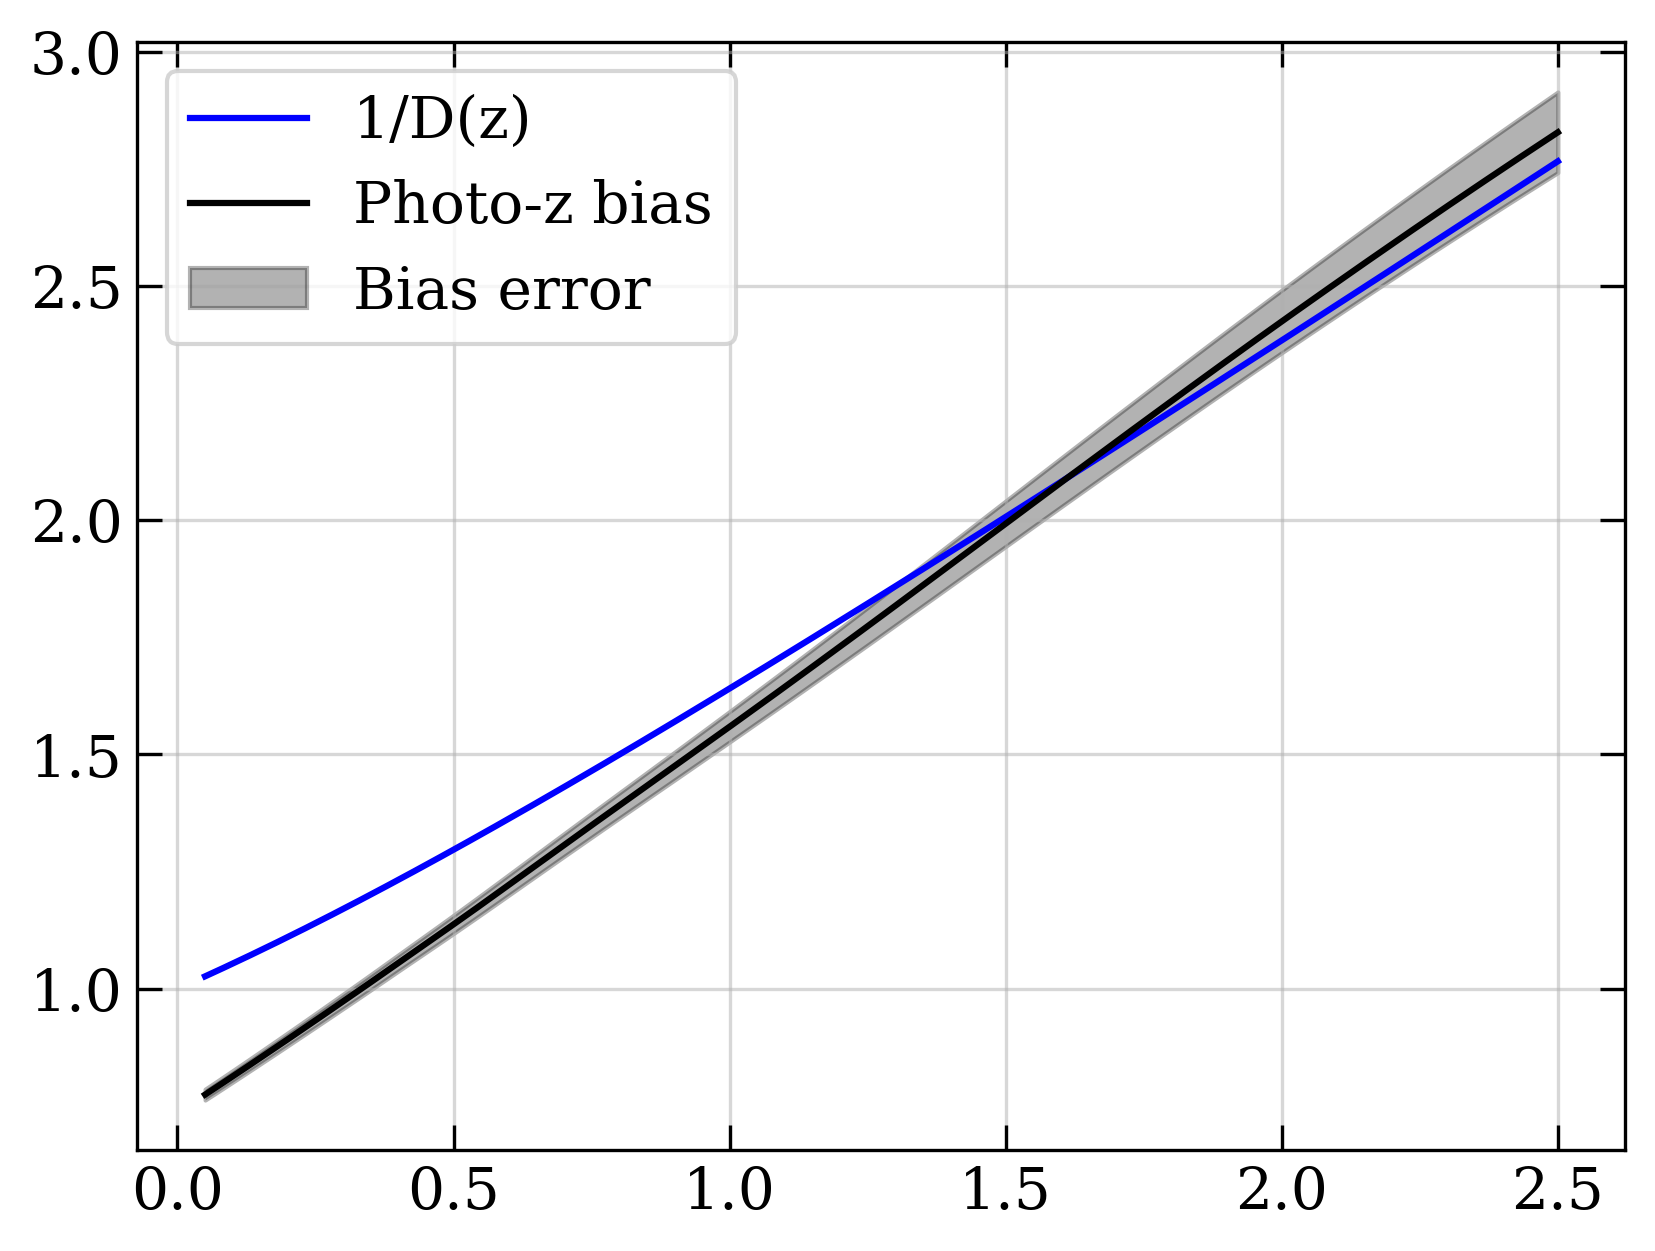

In [85]:
bias = lambda z: alpha*(1+z)**beta * np.sqrt(0.1/wdm_interpolator(z)) #dz=0.1
bias_err = bias(zv) * np.sqrt(
    (alpha_err / alpha)**2 +
    (beta_err * np.log(1 + zv))**2
)
zv = np.linspace(0.05, 2.5, 150)
import pyccl as ccl
gf = ccl.background.growth_factor(ct.COSMO_ccl, a=1/(1+zv))
plt.plot(zv, 1/gf, color='blue', label='1/D(z)')
plt.plot(zv, bias(zv), color='black', label='Photo-z bias')
plt.fill_between(zv, bias(zv) - bias_err, bias(zv) + bias_err, color='black', alpha=0.3, label='Bias error')
plt.legend(loc='upper left')

In [ ]:
importlib.reload(inference)
importlib.reload(comb)
wpp_scaled = []
wpp_err_scaled = []
wdm_arr = []

for i in range(1, len(vals_z_photo)+1):
    ## now let's get the wpp measurements to get the full correction
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['dr2']['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
        which_patches=[1,2,3,4]
    )
    wdm_eff = ct.w_dm(
        rp_vals=np.linspace(scale_cut[0], scale_cut[1], 100),
        z=vals_z_photo[i-1],
        integrate=True
    )
    wpp_err_scaled.append(wpp_err_meas*dz_phot/wdm_eff)
    wpp_scaled.append(wpp_meas*dz_phot/wdm_eff)
    wdm_arr.append(wdm_eff)
    
wpp_err_scaled = np.array(wpp_err_scaled)
wpp_scaled = np.array(wpp_scaled)
bpp = np.sqrt(wpp_scaled)
bpp_err = 1/(2* wpp_scaled ** (3/2)) * wpp_err_scaled

errs = comb.combine_error_bars_mult(wpp_scaled, wpp_err_scaled, corr_factor, corr_factor_err)
vals = np.sqrt(np.array(wpp_scaled)*(np.array(corr_factor)))

# polynomial fit to vals and errs
def poly_fit(x, a, b, c):
    return a * x**2 + b * x + c
def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

# Fit
popt, pcov = opt.curve_fit(poly_fit, vals_z_photo, vals, sigma=errs, absolute_sigma=True)
fit_vals = poly_fit(vals_z_photo, *popt)

# --- Uncertainty propagation ---
z = vals_z_photo
alpha, beta, gamma = popt
J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta
#fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

plt.figure(figsize=(6, 3.5))
plt.fill_between(
    vals_z_photo, 
    fit_vals,# - fit_sigma, 
    fit_vals,# + fit_sigma,
    color='gray', 
    alpha=0.5, 
)
plt.plot(vals_z_photo, fit_vals, color='black', label='Power law fit')
plt.errorbar(vals_z_photo, vals, errs, label='correction', capsize=3, fmt='o', color='blue', ms=2)
plt.errorbar(vals_z_photo, bpp, bpp_err, label='wpp', capsize=3, fmt='o', color='red', ms=2)
plt.legend(loc='upper left', fontsize=12)
plt.xlabel('Redshift')
plt.ylabel('b(z)')
plt.grid()

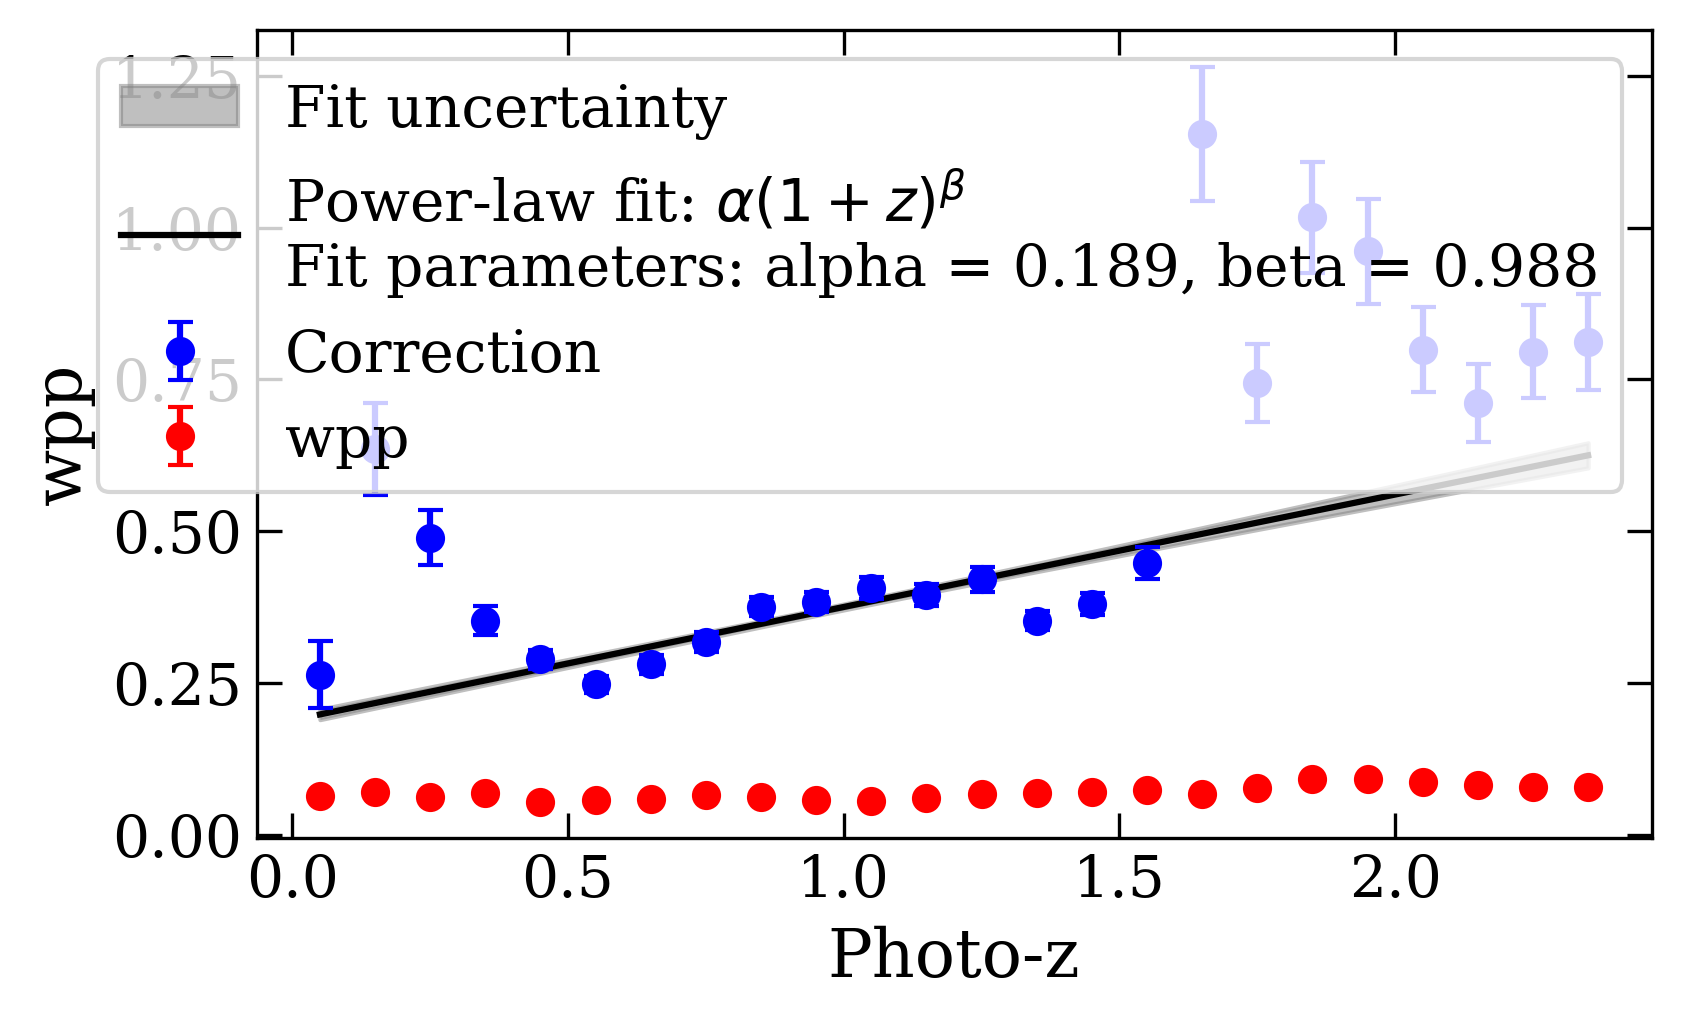

In [15]:
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['dr1']['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wpp_err_scaled.append(wpp_err_meas)
    wpp_scaled.append(wpp_meas)

wpp_scaled = np.array(wpp_scaled)
wpp_err_scaled = np.array(wpp_err_scaled)

# Combine errors and compute final correction values
vals = wpp_scaled * corr_factor
errs = np.sqrt((wpp_scaled * corr_factor_err)**2 + (wpp_err_scaled * corr_factor)**2)

def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

# Fit
popt, pcov = opt.curve_fit(powerlaw_1pz, vals_z_photo, vals, sigma=errs, absolute_sigma=True)
fit_vals = powerlaw_1pz(vals_z_photo, *popt)

# --- Uncertainty propagation ---
z = vals_z_photo
alpha, beta = popt
J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta
fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

plt.figure(figsize=(6, 3.5))
plt.fill_between(z, fit_vals - fit_sigma, fit_vals + fit_sigma, color='gray', alpha=0.5, label='Fit uncertainty')
plt.plot(z, 
         fit_vals, 
         color='black', 
         label='Power-law fit: $\\alpha(1+z)^\\beta$\n' 
         + f'Fit parameters: alpha = {popt[0]:.3f}, beta = {popt[1]:.3f}'
         )
plt.errorbar(z, vals, errs, fmt='o', color='blue', capsize=3, label='Correction')
plt.errorbar(z, wpp_scaled, wpp_err_scaled, fmt='o', color='red', capsize=3, label='wpp')
plt.xlabel('Photo-z')
plt.ylabel('wpp')
plt.grid()
plt.legend()

Fit parameters: alpha = 0.62832 ± 0.02301, beta = 0.21524 ± 0.05757


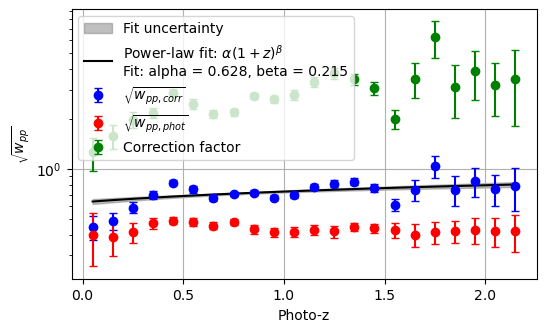

In [20]:
wpp_scaled = []
wpp_err_scaled = []

for i in range(1, len(vals_z_photo)+1):
    wpp_meas, wpp_err_meas, _ = inference.wpp(
        path=path_dictionary['HSC'],
        scale_cuts=scale_cut,
        bin_index=i,
    )
    wpp_err_scaled.append(wpp_err_meas)
    wpp_scaled.append(wpp_meas)

wpp_scaled = np.array(wpp_scaled)
wpp_err_scaled = np.array(wpp_err_scaled)
bpp = np.sqrt(wpp_scaled)
bpp_err = 1/(2* wpp_scaled ** (3/2)) * wpp_err_scaled
vals = np.sqrt(wpp_scaled * corr_factor)
errs = comb.combine_error_bars_mult(wpp_scaled, wpp_err_scaled, corr_factor, corr_factor_err)

def powerlaw_1pz(z, alpha, beta):
    return alpha * (1 + z) ** beta

# Fit
popt, pcov = opt.curve_fit(powerlaw_1pz, vals_z_photo, vals, sigma=errs, absolute_sigma=True)
fit_vals = powerlaw_1pz(vals_z_photo, *popt)

# --- Uncertainty propagation ---
z = vals_z_photo
alpha, beta = popt
J = np.empty((len(z), 2))
J[:, 0] = (1 + z) ** beta                          # ∂f/∂alpha
J[:, 1] = alpha * (1 + z) ** beta * np.log(1 + z)  # ∂f/∂beta
fit_sigma = np.sqrt(np.sum(J @ pcov * J, axis=1))

# get the error on parameters
param_errors = np.sqrt(np.diag(pcov))
print(f'Fit parameters: alpha = {popt[0]:.5f} ± {param_errors[0]:.5f}, beta = {popt[1]:.5f} ± {param_errors[1]:.5f}')

plt.figure(figsize=(6, 3.5))
plt.fill_between(z, fit_vals - fit_sigma, fit_vals + fit_sigma, color='gray', alpha=0.5, label='Fit uncertainty')
plt.plot(z, 
         fit_vals, 
         color='black', 
         label='Power-law fit: $\\alpha(1+z)^\\beta$\n' 
         + f'Fit: alpha = {popt[0]:.3f}, beta = {popt[1]:.3f}'
         )
plt.errorbar(z, vals, errs, fmt='o', color='blue', capsize=3, label=r'$\sqrt{w_{pp, corr}}$')
plt.errorbar(z, bpp, bpp_err, fmt='o', color='red', capsize=3, label=r'$\sqrt{w_{pp, phot}}$')
plt.errorbar(z, corr_factor, corr_factor_err, fmt='o', color='green', capsize=3, label=f'Correction factor')
plt.xlabel('Photo-z')
plt.yscale('log')
plt.ylabel(r'$\sqrt{w_{pp}}$')
plt.grid()
plt.legend()